# Proyecto Final — Clasificación de Sentimientos en Reseñas de Películas con Modelos Clásicos y Redes Neuronales Sencillas

**Alumno:** Alberto López Gutiérrez  
**Objetivo:** Desarrollar y evaluar un sistema de clasificación de sentimientos aplicado a reseñas de películas mediante técnicas de Procesamiento del Lenguaje Natural (PLN), comparando el desempeño de un modelo probabilístico basado en Naive Bayes y una red neuronal sencilla implementada con Keras, con el propósito de analizar sus fortalezas, limitaciones y comportamiento utilizando un conjunto de métricas de evaluación y técnicas de visualización aplicadas de manera uniforme a ambos modelos.

Este notebook cubre:

1. Preparación del entorno y descarga de recursos de NLTK.
2. Carga y exploración del conjunto de datos *movie_reviews*.
3. Preprocesamiento y limpieza de texto.
4. División del conjunto de datos en entrenamiento y prueba.
5. Representación vectorial mediante *CountVectorizer*.
6. Entrenamiento del modelo **Multinomial Naive Bayes**.
7. Construcción y entrenamiento de una **red neuronal** con Keras.
8. Aplicación de **EarlyStopping** para prevenir el sobreentrenamiento.
9. Evaluación comparativa mediante *Accuracy*, *Precision*, *Recall*, *F1-score* y *ROC-AUC*.
10. Construcción de matrices de confusión para ambos modelos.
11. Generación de curvas ROC comparativas.
12. Comparación final de resultados e interpretación de los modelos.
13. Prueba del modelo utilizando nuevas reseñas.

## 1. Preparación del entorno

La primera celda instala únicamente las librerías necesarias en el mismo kernel activo. Si ya están instaladas, `pip` solo verificará las dependencias.

In [29]:
%pip install -q nltk pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [30]:
import sys
import re
import string
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import movie_reviews, stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Entorno:", sys.executable)

Python: 3.11.15
Entorno: /opt/anaconda3/envs/iebs-tensorflow/bin/python


## 2. Descarga de recursos de NLTK

`movie_reviews` contiene 2,000 reseñas en inglés: 1,000 positivas y 1,000 negativas.

También se descargan:

- `stopwords`: palabras frecuentes con poco valor discriminativo.
- `punkt` y `punkt_tab`: recursos usados por el tokenizador de NLTK.

In [31]:
recursos_nltk = [
    "movie_reviews",
    "stopwords",
    "punkt",
    "punkt_tab"
]

for recurso in recursos_nltk:
    nltk.download(recurso, quiet=True)

print("Recursos de NLTK descargados correctamente.")

Recursos de NLTK descargados correctamente.


## 3. Carga y exploración del dataset

Cada reseña se almacena junto con su categoría original (`pos` o `neg`). Después se transforma la etiqueta a nombres más claros: `positivo` y `negativo`.

In [32]:
reviews = [
    (movie_reviews.raw(fileid), category)
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]

df = pd.DataFrame(reviews, columns=["review", "category"])
df["sentiment"] = df["category"].map({
    "pos": "positivo",
    "neg": "negativo"
})

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (2000, 3)


,review,category,sentiment
0,"plot : two teen couples go to a church party ,...",neg,negativo
1,the happy bastard's quick movie review \ndamn ...,neg,negativo
2,it is movies like these that make a jaded movi...,neg,negativo
3,""" quest for camelot "" is warner bros . ' firs...",neg,negativo
4,synopsis : a mentally unstable man undergoing ...,neg,negativo


In [33]:
print("Distribución de clases:")
display(df["sentiment"].value_counts().rename_axis("sentimiento").to_frame("cantidad"))

print("\nValores nulos:")
display(df.isna().sum().to_frame("cantidad"))

print("\nEjemplo de reseña:")
print(df.loc[0, "review"][:700])

Distribución de clases:


,cantidad
sentimiento,
negativo,1000
positivo,1000



Valores nulos:


,cantidad
review,0
category,0
sentiment,0



Ejemplo de reseña:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
the


### Interpretación inicial

El dataset está balanceado porque contiene la misma cantidad de reseñas positivas y negativas. Esto facilita la interpretación de la precisión y reduce el riesgo de que el modelo favorezca una clase únicamente por ser mayoritaria.

## 4. Preprocesamiento

Se aplican los pasos solicitados:

- Conversión a minúsculas.
- Eliminación de puntuación y números.
- Tokenización.
- Eliminación de stopwords en inglés.
- Conservación únicamente de tokens alfabéticos.

No se aplica stemming porque la consigna no lo exige y, en este caso, puede reducir la legibilidad de las palabras utilizadas posteriormente en las gráficas.

In [34]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    """Limpia y tokeniza una reseña en inglés."""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)
    tokens = [
        token
        for token in tokens
        if token.isalpha()
        and token not in stop_words
        and len(token) > 1
    ]

    return " ".join(tokens)

df["clean_review"] = df["review"].apply(preprocess_text)

display(df[["sentiment", "review", "clean_review"]].head(3))

,sentiment,review,clean_review
0,negativo,"plot : two teen couples go to a church party ,...",plot two teen couples go church party drink dr...
1,negativo,the happy bastard's quick movie review \ndamn ...,happy bastards quick movie review damn bug got...
2,negativo,it is movies like these that make a jaded movi...,movies like make jaded movie viewer thankful i...


In [35]:
print("Texto original:")
print(df.loc[0, "review"][:500])

print("\nTexto preprocesado:")
print(df.loc[0, "clean_review"][:500])

Texto original:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

Texto preprocesado:
plot two teen couples go church party drink drive get accident one guys dies girlfriend continues see life nightmares whats deal watch movie sorta find critique mindfuck movie teen generation touches cool idea presents bad package makes review even harder one write since generally applaud films attempt break mold mess head lost highway memento good bad ways making types films folks didnt snag one correctly seem taken pretty neat concept executed terribly pro

## 5. División de entrenamiento y prueba

Se reserva el 20% de las reseñas para prueba. Se usa `stratify` para conservar la misma proporción de clases en ambos conjuntos.

La división se realiza **antes de ajustar el vectorizador**, evitando que el vocabulario del conjunto de prueba influya en el entrenamiento.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=df["sentiment"]
)

print("Reseñas de entrenamiento:", len(X_train))
print("Reseñas de prueba:", len(X_test))

print("\nDistribución en entrenamiento:")
display(y_train.value_counts().to_frame("cantidad"))

print("Distribución en prueba:")
display(y_test.value_counts().to_frame("cantidad"))

Reseñas de entrenamiento: 1600
Reseñas de prueba: 400

Distribución en entrenamiento:


,cantidad
sentiment,
positivo,800
negativo,800


Distribución en prueba:


,cantidad
sentiment,
negativo,200
positivo,200


## 6. Vectorización con CountVectorizer

`CountVectorizer` convierte las reseñas en una matriz numérica de frecuencia de términos.

Parámetros principales:

- `min_df=2`: ignora palabras presentes en una sola reseña.
- `max_df=0.95`: elimina términos extremadamente comunes.
- `ngram_range=(1, 2)`: incluye palabras individuales y pares de palabras.
- `max_features=30000`: limita el tamaño del vocabulario para controlar el uso de memoria.

In [37]:
vectorizer = CountVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=30000
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("Forma de la matriz de entrenamiento:", X_train_vectorized.shape)
print("Forma de la matriz de prueba:", X_test_vectorized.shape)
print("Tamaño del vocabulario:", len(vectorizer.get_feature_names_out()))

Forma de la matriz de entrenamiento: (1600, 30000)
Forma de la matriz de prueba: (400, 30000)
Tamaño del vocabulario: 30000


## 7. Entrenamiento del modelo Naive Bayes

Se utiliza `MultinomialNB`, una variante de Naive Bayes apropiada para conteos de palabras y matrices dispersas generadas por `CountVectorizer`.

In [38]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

y_pred = model.predict(X_test_vectorized)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [39]:
# Probabilidades del modelo Naive Bayes
y_prob_nb = model.predict_proba(X_test_vectorized)[:, 1]

print("Primeras probabilidades:")
print(y_prob_nb[:5])

Primeras probabilidades:
[1.26546441e-22 3.87569578e-28 1.00000000e+00 1.00000000e+00
 3.28158445e-37]


## 8. Entrenamiento de la Red Neuronal (Keras)

Para comparar el modelo probabilístico de Naive Bayes con un enfoque basado en aprendizaje profundo, se implementa una red neuronal densa sencilla utilizando la API Sequential de Keras.

La red utiliza como entrada la misma representación vectorial generada mediante CountVectorizer, con el propósito de mantener condiciones comparables entre ambos modelos.

In [40]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Semillas para mejorar la reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.21.0


In [41]:
# Conversión de las matrices dispersas a matrices densas
X_train_nn = X_train_vectorized.astype("float32").toarray()
X_test_nn = X_test_vectorized.astype("float32").toarray()

# Conversión de las etiquetas a valores numéricos
y_train_nn = y_train.map({
    "negativo": 0,
    "positivo": 1
}).astype("float32").to_numpy()

y_test_nn = y_test.map({
    "negativo": 0,
    "positivo": 1
}).astype("float32").to_numpy()

print("Forma de X_train_nn:", X_train_nn.shape)
print("Forma de X_test_nn:", X_test_nn.shape)
print("Forma de y_train_nn:", y_train_nn.shape)
print("Forma de y_test_nn:", y_test_nn.shape)

Forma de X_train_nn: (1600, 30000)
Forma de X_test_nn: (400, 30000)
Forma de y_train_nn: (1600,)
Forma de y_test_nn: (400,)


In [42]:
model_nn = Sequential([
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_nn.shape[1],)
    ),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │     1,920,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,922,177 (7.33 MB)

 Trainable params: 1,922,177 (7.33 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

historial_nn = model_nn.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6656 - loss: 0.6085 - val_accuracy: 0.8406 - val_loss: 0.4630
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9047 - loss: 0.2762 - val_accuracy: 0.8656 - val_loss: 0.4020
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9766 - loss: 0.0988 - val_accuracy: 0.8594 - val_loss: 0.4457
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9898 - loss: 0.0466 - val_accuracy: 0.8375 - val_loss: 0.5475
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9953 - loss: 0.0307 - val_accuracy: 0.8438 - val_loss: 0.5699


In [44]:
# Probabilidades de pertenecer a la clase positiva
y_prob_nn = model_nn.predict(X_test_nn, verbose=0).ravel()

# Conversión de probabilidades en clases
y_pred_nn_num = (y_prob_nn >= 0.5).astype(int)

# Etiquetas textuales para facilitar la comparación
y_pred_nn = np.where(
    y_pred_nn_num == 1,
    "positivo",
    "negativo"
)

print("Predicciones generadas:", len(y_pred_nn))
print("Primeras probabilidades:", y_prob_nn[:5])
print("Primeras predicciones:", y_pred_nn[:5])

Predicciones generadas: 400
Primeras probabilidades: [0.02309409 0.03487403 0.93772805 0.81148225 0.00479249]
Primeras predicciones: ['negativo' 'negativo' 'positivo' 'positivo' 'negativo']


## 9. Evaluación comparativa de modelos

Se calculan:

- **Accuracy:** proporción total de predicciones correctas.
- **F1-score macro:** promedio del F1 de ambas clases, dando el mismo peso a positivo y negativo.
- **Reporte de clasificación:** precisión, recall y F1-score por clase.

In [45]:
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy:          {accuracy:.4f}")
print(f"F1-score macro:    {f1_macro:.4f}")
print(f"F1-score weighted: {f1_weighted:.4f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy:          0.8100
F1-score macro:    0.8098
F1-score weighted: 0.8098

Reporte de clasificación:

              precision    recall  f1-score   support

    negativo     0.8298    0.7800    0.8041       200
    positivo     0.7925    0.8400    0.8155       200

    accuracy                         0.8100       400
   macro avg     0.8111    0.8100    0.8098       400
weighted avg     0.8111    0.8100    0.8098       400



### Interpretación de los resultados

- Un accuracy cercano a 1 indica un porcentaje elevado de clasificaciones correctas.
- El F1-score combina precisión y recall; es útil para comprobar que el desempeño sea equilibrado.
- La matriz de confusión permite observar cuántas reseñas positivas y negativas fueron confundidas por el modelo.
- Debido a que el dataset está balanceado, accuracy y F1-score deberían presentar valores relativamente cercanos.

### Comparación entre Naive Bayes y la Red Neuronal

Una vez entrenados ambos modelos, se realiza una comparación utilizando las principales métricas de clasificación para evaluar su desempeño sobre el mismo conjunto de prueba.

Las métricas consideradas son:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Además, posteriormente se compararán las matrices de confusión y las curvas ROC de ambos modelos.

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

In [47]:
def evaluar_modelo(
    nombre,
    y_real,
    y_pred,
    y_prob
):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(
            y_real,
            y_pred,
            pos_label="positivo"
        ),
        "Recall": recall_score(
            y_real,
            y_pred,
            pos_label="positivo"
        ),
        "F1-score": f1_score(
            y_real,
            y_pred,
            pos_label="positivo"
        ),
        "ROC-AUC": roc_auc_score(
            LabelEncoder().fit_transform(y_real),
            y_prob
        )
    }

In [48]:
metricas_nb = evaluar_modelo(
    "Naive Bayes",
    y_test,
    y_pred,
    y_prob_nb
)

metricas_nn = evaluar_modelo(
    "Red Neuronal",
    y_test,
    y_pred_nn,
    y_prob_nn
)

In [49]:
comparacion = pd.DataFrame([
    metricas_nb,
    metricas_nn
])

comparacion = comparacion.round(4)

display(comparacion)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.8100,0.7925,0.840,0.8155,0.8870
1,Red Neuronal,0.8275,0.7835,0.905,0.8399,0.9175


### Matrices de confusión

Las matrices de confusión permiten observar la cantidad de predicciones correctas e incorrectas realizadas por cada modelo para las clases positiva y negativa.

Esta visualización complementa las métricas anteriores, ya que permite identificar de forma directa los falsos positivos y falsos negativos generados por Naive Bayes y por la red neuronal.

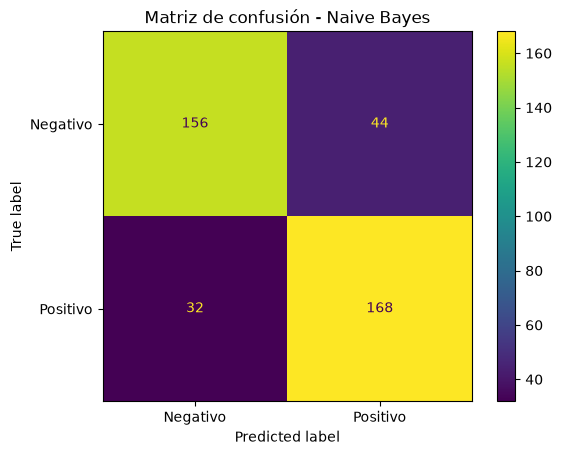

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(
    y_test,
    y_pred,
    labels=["negativo", "positivo"]
)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negativo", "Positivo"]
)

disp_nb.plot(values_format="d")
plt.title("Matriz de confusión - Naive Bayes")
plt.show()

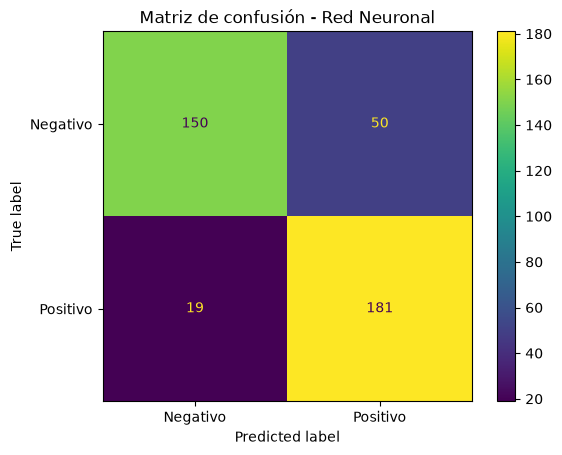

In [51]:
cm_nn = confusion_matrix(
    y_test,
    y_pred_nn,
    labels=["negativo", "positivo"]
)

disp_nn = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=["Negativo", "Positivo"]
)

disp_nn.plot(values_format="d")
plt.title("Matriz de confusión - Red Neuronal")
plt.show()

### Curvas ROC

La curva ROC representa la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales de clasificación.

El área bajo la curva, conocida como ROC-AUC, permite comparar la capacidad de los modelos para distinguir entre reseñas positivas y negativas. Un valor más cercano a 1 indica una mejor capacidad de discriminación.

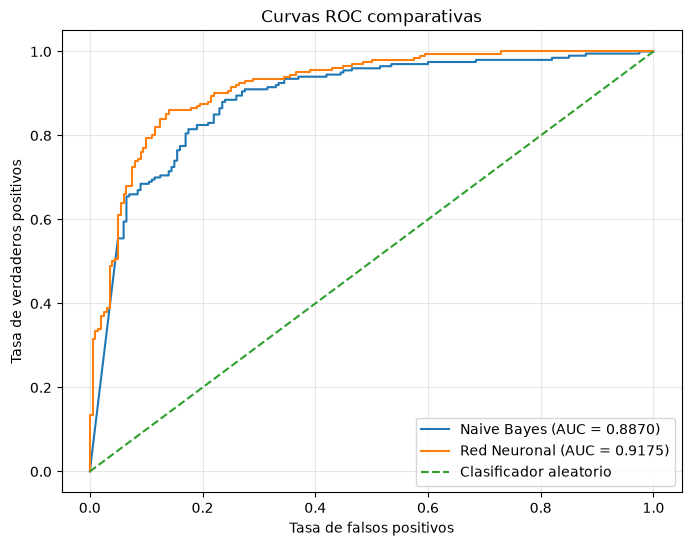

In [52]:
from sklearn.metrics import roc_curve, auc

# Conversión de las etiquetas reales a valores binarios
y_test_binary = y_test.map({
    "negativo": 0,
    "positivo": 1
}).to_numpy()

# Curva ROC de Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(
    y_test_binary,
    y_prob_nb
)

# Curva ROC de la red neuronal
fpr_nn, tpr_nn, _ = roc_curve(
    y_test_binary,
    y_prob_nn
)

auc_nb = auc(fpr_nb, tpr_nb)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes (AUC = {auc_nb:.4f})"
)

plt.plot(
    fpr_nn,
    tpr_nn,
    label=f"Red Neuronal (AUC = {auc_nn:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Discusión de resultados

Los resultados muestran que ambos modelos obtuvieron un desempeño satisfactorio al clasificar las reseñas del conjunto de prueba.

Naive Bayes alcanzó una precisión ligeramente superior, lo que indica una menor proporción de falsos positivos. Por su parte, la red neuronal obtuvo mejores valores de accuracy, recall, F1-score y ROC-AUC, demostrando una mayor capacidad para identificar correctamente las reseñas positivas.

Aunque la red neuronal requiere un entrenamiento más costoso y presenta una arquitectura considerablemente más compleja, consiguió un mejor desempeño general sobre este conjunto de datos.

En contraste, Naive Bayes continúa siendo una alternativa muy competitiva debido a su simplicidad, rapidez de entrenamiento y bajo costo computacional.

### Interpretación de las matrices de confusión y las curvas ROC

Las matrices de confusión muestran que ambos modelos logran clasificar correctamente la mayoría de las reseñas del conjunto de prueba.

La red neuronal presenta una mayor capacidad para identificar reseñas positivas, lo que coincide con su valor superior de recall. Sin embargo, esta mejora también provoca un mayor número de falsos positivos, razón por la cual su precision es ligeramente inferior a la obtenida por Naive Bayes.

La curva ROC confirma que la red neuronal posee una mayor capacidad general para distinguir entre reseñas positivas y negativas. Su valor ROC-AUC es superior al de Naive Bayes, lo que indica un mejor comportamiento al considerar diferentes umbrales de clasificación.

A pesar de esta mejora, Naive Bayes continúa mostrando un desempeño competitivo con una arquitectura mucho más sencilla y un menor costo computacional.

## 10. Palabras más frecuentes por sentimiento

Para que las gráficas sean comprensibles se cuentan únicamente unigramas del texto preprocesado. Se muestran las 20 palabras más frecuentes en reseñas positivas y negativas.

In [53]:
def get_top_words(text_series, top_n=20):
    counter = Counter()
    for text in text_series:
        counter.update(text.split())
    return pd.DataFrame(
        counter.most_common(top_n),
        columns=["palabra", "frecuencia"]
    )

positive_words = get_top_words(
    df.loc[df["sentiment"] == "positivo", "clean_review"],
    top_n=20
)

negative_words = get_top_words(
    df.loc[df["sentiment"] == "negativo", "clean_review"],
    top_n=20
)

display(positive_words)
display(negative_words)

,palabra,frecuencia
0,film,4867
1,one,2904
2,movie,2392
3,like,1719
4,story,1216
5,also,1200
6,films,1199
7,good,1193
8,even,1174
9,time,1171


,palabra,frecuencia
0,film,3994
1,movie,3048
2,one,2617
3,like,1835
4,even,1381
5,good,1128
6,time,1112
7,would,1049
8,get,1037
9,bad,1019


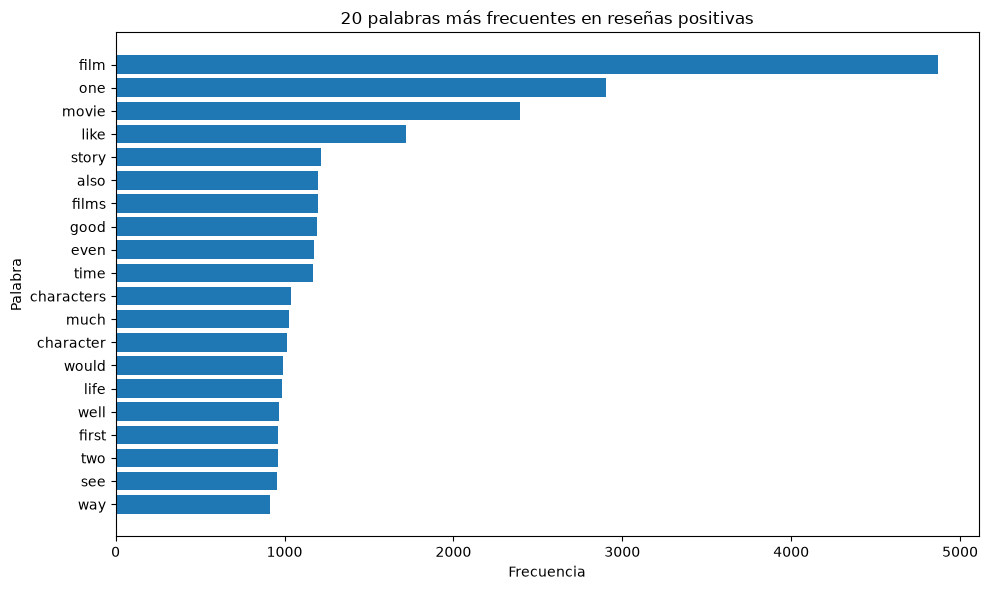

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(
    positive_words["palabra"][::-1],
    positive_words["frecuencia"][::-1]
)
plt.title("20 palabras más frecuentes en reseñas positivas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()

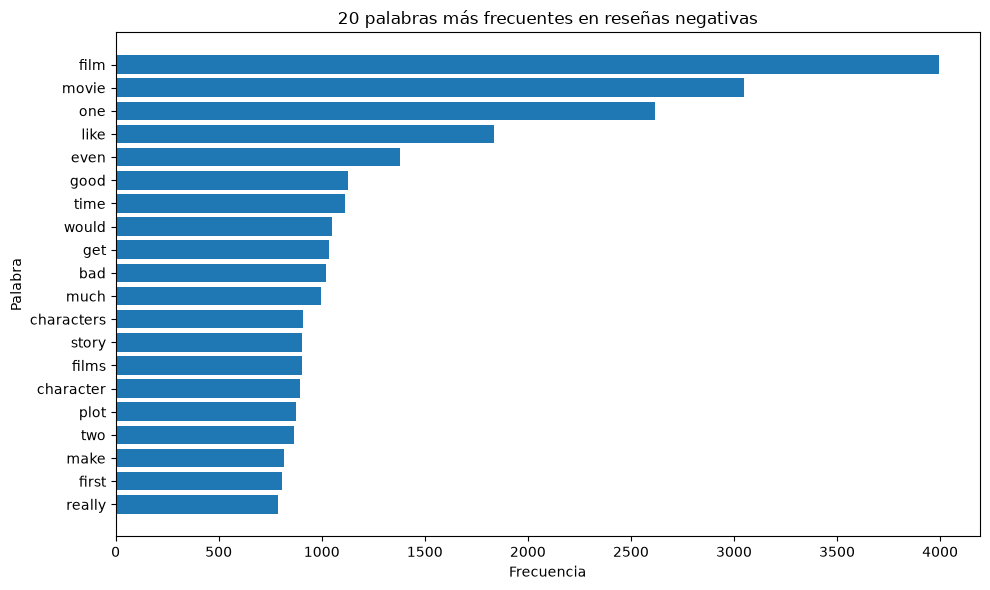

In [55]:
plt.figure(figsize=(10, 6))
plt.barh(
    negative_words["palabra"][::-1],
    negative_words["frecuencia"][::-1]
)
plt.title("20 palabras más frecuentes en reseñas negativas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()

### Observación sobre las palabras frecuentes

Es normal que varias palabras aparezcan en ambas categorías. La clasificación no depende únicamente de una palabra aislada, sino de la combinación de frecuencias aprendidas para miles de términos y bigramas.

## 11. Prueba con reseñas nuevas

La siguiente función aplica exactamente el mismo preprocesamiento y vectorización usados durante el entrenamiento.

In [56]:
def predict_sentiment(text):
    clean_text = preprocess_text(text)
    vector = vectorizer.transform([clean_text])
    prediction = model.predict(vector)[0]
    probabilities = model.predict_proba(vector)[0]

    probability_by_class = dict(
        zip(model.classes_, probabilities)
    )

    return {
        "texto": text,
        "prediccion": prediction,
        "probabilidad_negativo": probability_by_class.get("negativo", 0),
        "probabilidad_positivo": probability_by_class.get("positivo", 0)
    }

examples = [
    "The movie was wonderful, emotional and beautifully acted.",
    "This film was boring, predictable and a complete waste of time."
]

results = pd.DataFrame(
    [predict_sentiment(text) for text in examples]
)

display(results)

,texto,prediccion,probabilidad_negativo,probabilidad_positivo
0,"The movie was wonderful, emotional and beautif...",positivo,0.060819,0.939181
1,"This film was boring, predictable and a comple...",negativo,0.999257,0.000743


## 12. Conclusiones

En este proyecto se desarrollaron y compararon dos modelos de clasificación de sentimientos utilizando las 2,000 reseñas del corpus `movie_reviews` de NLTK: un modelo Multinomial Naive Bayes y una red neuronal densa implementada con Keras.

El proceso incluyó la exploración del conjunto de datos, la limpieza y normalización de los textos, la eliminación de stopwords y la representación de las reseñas mediante CountVectorizer. Ambos modelos fueron entrenados y evaluados sobre la misma división de datos, lo que permitió realizar una comparación bajo condiciones equivalentes.

Naive Bayes obtuvo un accuracy de 0.8100 y un ROC-AUC de 0.8870. Estos resultados confirman que se trata de una alternativa sencilla, rápida y competitiva para establecer una línea base en problemas de clasificación textual.

La red neuronal alcanzó un accuracy de 0.8275 y un ROC-AUC de 0.9175, además de un recall de 0.9050 para la clase positiva. Esto demuestra una mayor capacidad para identificar reseñas positivas y distinguir entre ambas clases. Sin embargo, también produjo un mayor número de falsos positivos y requirió más recursos computacionales y un proceso de entrenamiento considerablemente más complejo.

Los resultados muestran que una arquitectura más compleja puede mejorar el desempeño general, pero no necesariamente supera al modelo más sencillo en todas las métricas. Por esta razón, la selección del modelo debe considerar no solo su exactitud, sino también el tipo de error que se desea reducir, los recursos disponibles y las necesidades específicas del problema.

Entre las limitaciones del proyecto se encuentran el tamaño reducido y la antigüedad del corpus, así como la dificultad de ambos modelos para interpretar sarcasmo, ambigüedad, negaciones complejas y dependencias contextuales de largo alcance. Como trabajo futuro, podrían evaluarse representaciones como TF-IDF, embeddings y modelos basados en arquitecturas recurrentes o Transformers.